In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

Set BCH-specific variables.

In [12]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                #             'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                # 'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                #   'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                #     'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                #     'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                #     'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                #     'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                #     'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                #     'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                                    'physician_or_hospital_referral'
                    ]

#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 'max_early_chews_score', #Leave out pseudo-nedocs
     'num_previous_admissions', 'num_previous_visits_without_admission',
    'max_dbp',
    'max_hr',
    'max_pain',
    'max_rr',
    'max_sbp',
    'max_sp_o2',
    'mean_dbp',
    'mean_hr',
    'mean_pain',
    'mean_rr',
    'mean_sbp',
    'mean_sp_o2',
    'min_dbp',
    'min_hr',
    'min_pain',
    'min_rr',
    'min_sbp',
    'min_sp_o2'
]


#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}

#Choose the model to go forward with
target_model = 'XGBoost'


---LOAD FILES---

#Load in the pre-processed BCH data: pre-epic, with processed chief complaints and raw triage vitals; define outcomes.


In [49]:
#----LOAD RAW DATA------
visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)

#-----EXTRACT ADMIT SOURCES----------
admit_sources = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'ADMIT_SOURCE']].drop_duplicates().rename(
    columns={'CSN':'csn', 'ADMIT_SOURCE':'admit_source'}
)
admit_sources['physician_or_hospital_referral'] = admit_sources['admit_source'].isin(['Physician Referral', 'Hospital', 'Other Health Care Facility', 'Internal Transfer Med/Psych', 'Other Rehab Facility', 'Ambulatory Surgery Center'])
visits = visits.merge(admit_sources[['csn', 'physician_or_hospital_referral']], on='csn', how='left')
assert(visits['csn'].nunique() == len(visits))

#--------LOAD VITALS-------------
vitals = pd.read_csv(load_filepath + "intermediate-files/vitals-with-age-and-pain.csv", index_col=0, engine='pyarrow').rename(columns={
    'time_since_arrival':'timestamp',
    'measure': 'vital_type',
    'value':'vital_value'
})[['csn', 'arrival_time', 'vital_type', 'vital_value', 'age_in_days', 'timestamp']]
print("loaded vitals")

#Keep only vitals for included visits.
vitals = vitals.merge(visits[['csn']], on='csn', how='inner')

#Transform vitals to numeric.
vitals['vital_value'] = pd.to_numeric(vitals['vital_value'])



#-----LABEL VITAL OUTCOMES-------
# OUTCOME 1: Tachycardia definitions according to the ACLS:
vitals['tachycardia'] = ((vitals['vital_type']=='hr') & (
    ((vitals['age_in_days'] <= 120) & (vitals['vital_value'] >= 205)) | #Less than 4 months old, HR > 205 bpm
    ((vitals['age_in_days'] > 120) & (vitals['age_in_days'] <= 365.25*2) & (vitals['vital_value'] >= 190)) | #4 months to 2 years, HR > 190 bpm 
    ((vitals['age_in_days'] > 365.25*2) & (vitals['age_in_days'] <= 365.25*10) & (vitals['vital_value'] >= 140)) | #2-10 years, HR > 140 bpm
    ((vitals['age_in_days'] > 365.25*10) & (vitals['vital_value'] >= 100)))).astype(int) #Older than 10, HR > 100bpm
     

# OUTCOME 2a: Hypotension according to ACLS
vitals['hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 60)) | #Up to 4 days old, SBP < 60
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 70)) | #4 days to 6 months, SBP < 70
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (70 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 70 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 90)))).astype(int) #Older than 14, SBP < 90

# OUTCOME 2b: Hypotension according to Anne (ACLS-5)
vitals['severe_hypotension'] = ((vitals['vital_type']=='sbp') & (
    ((vitals['age_in_days'] <= 4) & (vitals['vital_value'] < 55)) | #Up to 4 days old, SBP < 55
    ((vitals['age_in_days'] > 4) & (vitals['age_in_days'] <= 365.25/2) & (vitals['vital_value'] < 65)) | #4 days to 6 months, SBP < 65
    ((vitals['age_in_days'] > 365.25/2) & (vitals['age_in_days'] <= 365.25*14) & (vitals['vital_value'] < (65 + 2*np.floor(vitals['age_in_days']/365.25)))) | #6 months to 14 years, SBP < 65 + 2*age in years (rounded)
    ((vitals['age_in_days'] > 365.25*14) & (vitals['vital_value'] < 85)))).astype(int) #Older than 14, SBP < 85


#OUTCOME 3: Hypoxia (SpO2 < 90)
vitals['hypoxia'] = ((vitals['vital_type']=='sp_o2') & (vitals['vital_value'] < 85)).astype(int)


#-----GET VITALS IN FIRST 30 MINUTES------
early_vitals = vitals[vitals['timestamp'] <= 30].groupby(['csn', 'vital_type']).agg(
    max = ('vital_value', 'max'),
    mean = ('vital_value', 'mean'),
    min = ('vital_value', 'min')
).reset_index()

early_vitals = early_vitals.pivot_table(
    index = 'csn',
    columns = 'vital_type',
    values = ['max', 'mean', 'min']
).reset_index()

early_vitals.columns = [
    '_'.join(col).strip('_') if col[1] else col[0]
    for col in early_vitals.columns
]
visits = visits.merge(early_vitals, on='csn', how='left')

#----GET MAX CHEWS SCORE AND PAIN IN FIRST 30 MINUTES-----
scores = pd.read_csv(raw_filepath + "LaCava_Scores_May7.csv", engine='pyarrow')
chews = scores[(scores['SCORE_VARIABLE']=='CHEWS-  Score')][['CSN','SCORE', 'SCORE_DT_TIME']].merge(
    vitals[['csn', 'arrival_time']].drop_duplicates(), left_on='CSN', right_on='csn', how='inner'
)
chews['timestamp'] = (
    pd.to_datetime(chews['SCORE_DT_TIME']) - pd.to_datetime(chews['arrival_time'])
).dt.total_seconds() / 60

chews = chews[['CSN', 'SCORE', 'timestamp']].copy().rename(
    columns={'CSN':'csn', 'SCORE':'score'}
)
chews = chews[chews['timestamp'] <= 30].groupby('csn').agg(
    max_early_chews_score = ('score', 'max') 
).reset_index()
visits = visits.merge(chews, on='csn', how='left')

#---SAVE VITALS------
vitals.to_csv(save_filepath + 'intermediate-files/vitals.csv')
print("marked vital outcomes")

#-----GET POST VISIT OUTCOMES------
dispositions = pd.read_csv(raw_filepath + "LaCava_Dispositions_Aug7.csv", index_col=0, engine='pyarrow')
print("loaded dispositions")

#Attach CSNs to disposition tables.
raw_visits = pd.read_csv(raw_filepath + "LaCava_Demopgraphics_May1_V1.csv", engine='pyarrow')[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']].drop_duplicates()
dispositions = dispositions.rename(columns={'ED_CHECKIN_DT_TM':'ED_ARRIVAL_TIME'}).merge(
    raw_visits[['CSN', 'NAME', 'DOB', 'ED_ARRIVAL_TIME']], on=['NAME', 'DOB', 'ED_ARRIVAL_TIME'], how='inner').rename(
        columns={'CSN':'csn'}
    )

#We are interested in patients who were ever admitted to an ICU during their stay, or who died.
all_icus = ['11SOUTH MICU', '7S MED/SURG ICU', '8S CARDIAC ICU', '7N NEONATAL ICU', 
            'LW 11 BERTHIAUME', #MICU
            'LW 07 HALE', 'LW 08A HALE', #CICU
            'LW 07 BERTHIAUME', 'LW 08 BERTHIAUME', #MSICU
            'LW 11 HALE' #NICU
            ]

#OUTCOME 4: ICU transfer during the hospital stay (assuming admission at least 60 mins into stay)
dispositions['ed_los'] = (
    pd.to_datetime(dispositions['ED_CHECKOUT_DT_TM']) - pd.to_datetime(dispositions['ED_ARRIVAL_TIME'])
).dt.total_seconds() / 60
dispositions['icu'] = ((
    dispositions['DEPT_NAME'].isin(all_icus) | 
    dispositions['NEXT_DEPARTMENT_NAME'].isin(all_icus)
))

icu_admission = (
    dispositions.groupby('csn')['icu']
    .any()
    .astype(int)
    .reset_index()
)

#Get length of stay (assuming only 1 ED checkout, first one is controlling)
ed_los = dispositions.groupby('csn')['ed_los'].agg('min').reset_index() #Assume 
icu_admission = icu_admission.merge(ed_los, on='csn', how='inner')
icu_admission['icu'] = ((icu_admission['icu'] == 1) & (icu_admission['ed_los'] >= 60)).astype(int)
icu_admission = icu_admission[['csn', 'icu']].copy()


#OUTCOME 5: death following hospital admission.
dispositions['death'] = (dispositions['DISCHARGE_DISPOSITION_DESC'] == 'Deceased')
deaths = dispositions.groupby('csn')['death'].any().astype(int).reset_index()

#Save in-hospital outcomes.
in_hospital_outcomes = pd.merge(icu_admission, deaths, on='csn', how='left')
in_hospital_outcomes.to_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv')

print('saved in-hospital outcomes')

#OUTCOME 6: INTUBATION DURING ED STAY (after at least 60 minutes)
medications = pd.read_csv(load_filepath+"prediction/medications.csv", engine="pyarrow")
medications['intubation'] = (medications['medroute'].isin([
    'ROCURONIUM_IV', 'ETOMIDATE_IV', 'ROCURONIUM 10 MG/ML INTRAVENOUS SOLUTION_IV', 'ETOMIDATE 2 MG/ML INTRAVENOUS SOLUTION_IV',
])) & (medications['timestamp'] >= 60)
intubations = medications.groupby('csn')['intubation'].any().astype(int).reset_index()
intubations.to_csv(save_filepath+'intermediate-files/intubation.csv')


#OUTCOME 7: SHOCK TREATMENT 
medications['vasopressor'] = ((
    (medications['medroute'].str.contains("EPINEPHRINE") & ((medications['medroute'].str.contains("_IV")) | medications['medroute'].str.contains("_INTRAMUSCULAR"))) | #epinephrine IM or IV
    (medications['medroute'].str.contains("NOREPINEPHRINE") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("DOPAMINE") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("VASOPRESSIN") & medications['medroute'].str.contains("_IV")) | 
    (medications['medroute'].str.contains("MILRINONE") & medications['medroute'].str.contains("_IV")) ) & (medications['timestamp'] >= 60))
vasopressors = medications.groupby('csn')['vasopressor'].any().astype(int).reset_index()
vasopressors.to_csv(save_filepath+'intermediate-files/vasopressors.csv')

#---GET ED_LOS-----
visits = visits.merge(ed_los, on="csn", how='inner')

#Save this.
#Keep CSNs and then legal predictors.
visits = visits[['csn', 'mrn', 'is_admitted', 'minutes_since_first_arrival', 'ed_los'] + pre_binarised_predictors + categorical_predictors + continuous_predictors]
assert(visits['csn'].nunique() == len(visits))
visits.to_csv(save_filepath + 'intermediate-files/visits.csv')

loaded vitals
marked vital outcomes
loaded dispositions
saved in-hospital outcomes


Identify initially stable children from their initial vitals. Criteria are:

--younger than 18
--triage acuity less than 2 (i.e. 3-5)
--no instability in first 30 minutes


We assume the record is complete within 30 minutes of arrival and thus take only information (vitals, CHEWS scores etc) taken before that.

We aim to identify children with hypoxia or hypotension recorded after the first 60 minutes, OR intubation/vasoactives (from proxies), OR eventual ICU admission, OR death.


In [6]:
#Load visits and vitals.
visits = pd.read_csv(save_filepath+'intermediate-files/visits.csv', index_col=0, engine='pyarrow')
vitals = pd.read_csv(save_filepath + 'intermediate-files/vitals.csv', index_col=0, engine='pyarrow')

print("Initially: " + str(len(visits)) + " visits")

#Criteria 1 & 2: pediatric patients with triage acuity known, 3-5
visits = visits[(visits['age_in_days'] < 18*365.25) & (visits['triage_acuity'].values > 2) & ~visits['triage_acuity'].isna()].copy()

print("After C1&2: " +  str(len(visits))  + " visits")

#Criterion 3: no instability in the first 30 minutes.
#Define instability as Bischops hypotension or hypoxia.
vitals['unstable'] = (vitals['severe_hypotension'] + vitals['hypoxia'] > 0)
vitals['initial_instability'] = ((vitals['timestamp'] <= 30) & vitals['unstable'])
initial_instability = vitals.groupby('csn')['initial_instability'].any().astype(int).reset_index()
visits = visits.merge(initial_instability[['csn', 'initial_instability']], how='left', on='csn') #Left-merge to ensure those with no vitals are kept.
visits['initial_instability'] = visits['initial_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits = visits[visits['initial_instability']==0].copy().drop(columns=['initial_instability'])



print("After C3: " + str(len(visits))  + " visits")
#Save eligible visits.
visits.to_csv(save_filepath+'intermediate-files/eligible-visits.csv')

#Edge case: new instability 30-60 minutes.
vitals['edge_case_instability'] = ((vitals['timestamp'] >= 30) & (vitals['timestamp'] <= 60) & (vitals['unstable']))
new_instability = vitals.groupby('csn')['edge_case_instability'].any().astype(int).reset_index()
edge_case_visits = visits.merge(new_instability[['csn', 'edge_case_instability']], how='left', on='csn')

print("Visits with instabilities between 30-60 minutes")
print(edge_case_visits['edge_case_instability'].sum())
print(edge_case_visits['edge_case_instability'].mean())


#Edge case: visit shorter than 60 minutes.
print("Visits shorter than 60 minutes")
print((visits['ed_los'] <= 60).sum())
print((visits['ed_los'] <= 60).mean())

#Outcome: new instability after the 60 minute mark.
vitals['new_instability'] = ((vitals['timestamp'] > 60) & (vitals['unstable']))
new_instability = vitals.groupby('csn')['new_instability'].any().astype(int).reset_index()
visits = visits.merge(new_instability[['csn', 'new_instability']], how='left', on='csn')

#Outcome: intubation, vasopressor administration, ICU transfer, or death.
in_hospital_outcomes = pd.read_csv(save_filepath+'intermediate-files/in-hospital-outcomes.csv', index_col=0)
intubations = pd.read_csv(save_filepath+'intermediate-files/intubation.csv', index_col=0)
vasopressors = pd.read_csv(save_filepath+'intermediate-files/vasopressors.csv', index_col=0)

#Join this.
visits = visits.merge(in_hospital_outcomes, on='csn', how='left').merge(intubations, on='csn', how='left').merge(vasopressors, on='csn', how='left')

#Again:
visits['new_instability'] = visits['new_instability'].fillna(0) #No affirmative record of an instability -> no instability
visits['intubation'] = visits['intubation'].fillna(0)
visits['death'] = visits['death'].fillna(0)
visits['icu'] = visits['icu'].fillna(0)
visits['vasopressor'] = visits['vasopressor'].fillna(0)
visits['any_outcome'] = (visits[['new_instability', 'intubation', 'vasopressor', 'icu', 'death']].sum(axis=1) > 0)


print("After outcomes: " + str(len(visits))  + " visits")

#Number days consecutively.
linkage = pd.read_csv(save_filepath+'intermediate-files/linkage.csv')[['CSN', 'ED_ARRIVAL_TIME']].drop_duplicates().rename(columns={
    'CSN':'csn'
})
visits = visits.merge(linkage, on='csn', how='inner')
visits['ED_ARRIVAL_TIME'] = pd.to_datetime(visits['ED_ARRIVAL_TIME'])
visits['day_number'] = (visits['ED_ARRIVAL_TIME'].dt.normalize() - visits['ED_ARRIVAL_TIME'].dt.normalize().min()).dt.days + 1 #Normalise strips all dates to midnight.

print("After linkage: " + str(len(visits))  + " visits")

#Save these.
visits.to_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv')



Initially: 305963 visits
After C1&2: 211865 visits
After C3: 211243 visits
Visits with instabilities between 30-60 minutes
121.0
0.0005729980584363309
Visits shorter than 60 minutes
6257
0.02961991639959667
After outcomes: 211243 visits


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_2190/3609667533.py:67: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


After linkage: 211243 visits


Describe the cohort.

In [92]:
"""
Generate a "Table 1" style cohort characteristics summary (CSV + LaTeX)
describing the general properties of the ED visit cohort.

Assumes `visits` is a pandas DataFrame already loaded as in your snippet:

    visits = pd.read_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0)

and that the config variables from your settings file (race_dict,
identifier_cols, categorical_predictors, continuous_predictors, etc.)
are available in the namespace.

Outputs:
    <save_filepath>tables/cohort_characteristics.csv
    <save_filepath>tables/cohort_characteristics.tex
"""

import pandas as pd
import numpy as np
import os

# ---------------------------------------------------------------------------
# 0. Load data (comment out if `visits` is already in your namespace)
# ---------------------------------------------------------------------------
visits = pd.read_csv(save_filepath + 'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0)

out_dir = os.path.join(save_filepath, 'tables')
os.makedirs(out_dir, exist_ok=True)

n_total = len(visits)

# ---------------------------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------------------------

def fmt_n_pct(n, denom):
    """Format 'N (pct%)' with one decimal place on the percentage.
    Kept as a plain '%' here since this feeds both the CSV (where it should
    read normally) and the LaTeX table (where to_latex(escape=True) below
    takes care of turning it into '\\%')."""
    pct = 100.0 * n / denom if denom else float('nan')
    return f"{int(n)} ({pct:.1f}%)"


def categorical_block(series, label, denom=None, dropna=False, top_n=None,
                       other_label='Other/Unknown'):
    """
    Build a list of (row_label, value_string) tuples describing the
    distribution of a categorical variable, with an initial header row
    giving the variable name.
    """
    denom = denom if denom is not None else len(series)
    counts = series.value_counts(dropna=dropna)

    if top_n is not None and len(counts) > top_n:
        top = counts.iloc[:top_n]
        rest = counts.iloc[top_n:].sum()
        counts = pd.concat([top, pd.Series({other_label: rest})])

    rows = [(label, "")]
    for cat, n in counts.items():
        cat_label = "Missing" if pd.isna(cat) else str(cat)
        rows.append((f"    {cat_label}", fmt_n_pct(n, denom)))
    return rows


def continuous_block(series, label, decimals=2):
    """Build a single 'mean (SD)' row for a continuous variable."""
    s = series.astype(float)
    mean, sd = s.mean(), s.std()
    median, q1, q3 = s.median(), s.quantile(0.25), s.quantile(0.75)
    return [
        (label, ""),
        ("    Mean (SD)", f"{mean:.{decimals}f} ({sd:.{decimals}f})"),
        ("    Median (IQR)", f"{median:.{decimals}f} ({q1:.{decimals}f}\u2013{q3:.{decimals}f})"),
    ]


# ---------------------------------------------------------------------------
# 2. Derived variables
# ---------------------------------------------------------------------------

# --- Age groups, from age_in_days ---
age_bins = [
    -np.inf, 91.25, 182.5, 365, 547.5, 1095, 1825, 3650, 5475, np.inf
]
age_labels = [
    "0-3 mo", "3-6 mo", "6-12 mo", "12-18 mo", "18-36 mo",
    "3-5 y", "5-10 y", "10-15 y", "15+ y"
]
if 'age_in_days' in visits.columns:
    visits['age_group'] = pd.cut(
        visits['age_in_days'], bins=age_bins, labels=age_labels, right=False
    )

# --- Most common chief complaint(s) ---
# Handles either (a) a single 'chief_complaint' text column, or
# (b) a set of one-hot 'complaint_contains_*' columns as in the settings file.
complaint_cols = [c for c in visits.columns if c.startswith('complaint_contains_')]

# ---------------------------------------------------------------------------
# 3. Build the table, as a list of "blocks" (one block per variable) so that
#    a variable's header + its categories never get split apart when we lay
#    the table out in two side-by-side halves below.
# ---------------------------------------------------------------------------

blocks = []  # list of list-of-(label, value) tuples

blocks.append([("Total N", f"{n_total}")])

# Sex
if 'sex' in visits.columns:
    blocks.append(categorical_block(visits['sex'], "Sex"))

# Race
if 'race' in visits.columns:
    blocks.append(categorical_block(visits['race'], "Race/ethnicity"))

# Age group
if 'age_group' in visits.columns:
    age_rows = [("Age group", "")]
    counts = visits['age_group'].value_counts(dropna=False).reindex(age_labels + [np.nan])
    for cat, n in counts.items():
        if pd.isna(n):
            continue
        cat_label = "Missing" if pd.isna(cat) else str(cat)
        age_rows.append((f"    {cat_label}", fmt_n_pct(n, n_total)))
    blocks.append(age_rows)

# Triage acuity
if 'triage_acuity' in visits.columns:
    triage_series = visits['triage_acuity']
    # Cast whole-number floats (e.g. 3.0) to a nullable int dtype so labels
    # read "3" instead of "3.0", while preserving missing values.
    if pd.api.types.is_float_dtype(triage_series):
        triage_series = triage_series.astype('Int64')
    blocks.append(categorical_block(triage_series, "Triage acuity"))

# Any outcome
if 'any_outcome' in visits.columns:
    blocks.append(categorical_block(visits['any_outcome'].astype('boolean'), "Any outcome"))

# ED arrival mode
if 'ed_arrival_mode' in visits.columns:
    blocks.append(categorical_block(visits['ed_arrival_mode'], "ED arrival mode"))

# Most common chief complaint(s)
if 'chief_complaint' in visits.columns:
    blocks.append(categorical_block(visits['chief_complaint'], "Chief complaint", top_n=10))
elif complaint_cols:
    comp_counts = visits[complaint_cols].sum().sort_values(ascending=False)
    comp_rows = [("Chief complaint (top 10, non-exclusive categories)", "")]
    for col, n in comp_counts.head(10).items():
        label = col.replace('complaint_contains_', '').replace('_', ' ').capitalize()
        comp_rows.append((f"    {label}", fmt_n_pct(n, n_total)))
    blocks.append(comp_rows)

# Previous visit counts
if 'num_previous_admissions' in visits.columns:
    blocks.append(continuous_block(
        visits['num_previous_admissions'], "Previous admissions (last 30 days)"
    ))
if 'num_previous_visits_without_admission' in visits.columns:
    blocks.append(continuous_block(
        visits['num_previous_visits_without_admission'],
        "Previous ED visits without admission (last 30 days)"
    ))

# Language
if 'language' in visits.columns:
    blocks.append(categorical_block(visits['language'], "Language", top_n=8))

# Insurance
if 'insurance' in visits.columns:
    blocks.append(categorical_block(visits['insurance'], "Insurance"))

# Flatten blocks into a single row list (with a blank spacer row between
# blocks) for the CSV / flat representation.
rows = []
for i, block in enumerate(blocks):
    if i > 0:
        rows.append(("", ""))
    rows.extend(block)

# ---------------------------------------------------------------------------
# 4. Save as CSV
# ---------------------------------------------------------------------------

table_df = pd.DataFrame(rows, columns=["Characteristic", "Value"])
csv_path = os.path.join(out_dir, "cohort_characteristics.csv")
table_df.to_csv(csv_path, index=False)
print(f"Saved CSV to {csv_path}")

# ---------------------------------------------------------------------------
# 5. Print as a two-column-spanning LaTeX table (table*), split into two
#    side-by-side halves so a ~70-row table doesn't overflow a single
#    narrow column in a twocolumn document. Blocks (variables) are never
#    split across the two halves. Wrapped for PMLR's \floatconts macro.
# ---------------------------------------------------------------------------

def escape_latex(s):
    s = str(s)
    for a, b in [("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"),
                 ("_", r"\_"), ("#", r"\#"), ("$", r"\$")]:
        s = s.replace(a, b)
    return s


def split_blocks_evenly(block_list, n_parts=3):
    """Split blocks (in order, never splitting one apart) into n_parts
    contiguous groups so that the largest group is as small as possible
    (classic 'partition array to minimize max sum' via binary search)."""
    sizes = [len(b) for b in block_list]
    n = len(sizes)
    if n_parts >= n:
        parts = [[b] for b in block_list]
        while len(parts) < n_parts:
            parts.append([])
        return parts

    def parts_needed(cap):
        count, current = 1, 0
        for s in sizes:
            if current + s > cap:
                count += 1
                current = s
            else:
                current += s
        return count

    lo, hi = max(sizes), sum(sizes)
    while lo < hi:
        mid = (lo + hi) // 2
        if parts_needed(mid) <= n_parts:
            hi = mid
        else:
            lo = mid + 1
    cap = lo

    parts, current_part, current_sum = [], [], 0
    for block, size in zip(block_list, sizes):
        if current_part and current_sum + size > cap:
            parts.append(current_part)
            current_part, current_sum = [], 0
        current_part.append(block)
        current_sum += size
    if current_part:
        parts.append(current_part)
    while len(parts) < n_parts:
        parts.append([])
    return parts


N_GROUPS = 3
column_blocks = split_blocks_evenly(blocks, n_parts=N_GROUPS)

# Flatten each column-group's blocks into a single row list (with a blank
# spacer row between blocks within that group), then pad all groups to the
# same length so they can sit side-by-side in ONE tabular, row-aligned.
group_rows = []
for cb in column_blocks:
    grp = []
    for i, block in enumerate(cb):
        if i > 0:
            grp.append(("", ""))
        grp.extend(block)
    group_rows.append(grp)

max_len = max((len(g) for g in group_rows), default=0)
for g in group_rows:
    g.extend([("", "")] * (max_len - len(g)))

# Build ONE tabular spanning all groups side-by-side (no minipages, no
# \hfill -- a single real grid can't overlap the way independently-sized
# boxes can).
col_spec = "@{\\hspace{2em}}".join(["ll"] * N_GROUPS)
lines = [f"\\begin{{tabular}}{{{col_spec}}}", r"\toprule"]
header_cells = []
for _ in range(N_GROUPS):
    header_cells.extend(["Characteristic", "Value"])
lines.append(" & ".join(header_cells) + r" \\")
lines.append(r"\midrule")
for row_idx in range(max_len):
    cells = []
    for g in range(N_GROUPS):
        label, value = group_rows[g][row_idx]
        cells.append(escape_latex(label))
        cells.append(escape_latex(value))
    lines.append(" & ".join(cells) + r" \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
tabular_str = "\n".join(lines)

# Scale the whole grid to fit the available width exactly -- this guarantees
# it can never run off the page edge, regardless of how wide the raw
# content (long category labels, etc.) naturally is.
body = (
    r"\resizebox{\linewidth}{!}{%" + "\n"
    + tabular_str + "\n"
    r"}"
)

# [p] dedicates a full page to this float rather than letting it interleave
# with the surrounding two-column body text.
latex_str = (
    "\\begin{table*}[p]\n"
    "\\floatconts\n"
    "  {tab:cohort-characteristics}\n"
    "  {\\caption{Cohort characteristics}}\n"
    "  {" + body + "\n  }\n"
    "\\end{table*}"
)
print(latex_str)

tex_path = os.path.join(out_dir, "cohort_characteristics.tex")
with open(tex_path, "w") as f:
    f.write(latex_str)
print(f"Saved LaTeX table to {tex_path}")

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_77972/1777198617.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Saved CSV to /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/tables/cohort_characteristics.csv
\begin{table*}[p]
\floatconts
  {tab:cohort-characteristics}
  {\caption{Cohort characteristics}}
  {\resizebox{\linewidth}{!}{%
\begin{tabular}{ll@{\hspace{2em}}ll@{\hspace{2em}}ll}
\toprule
Characteristic & Value & Characteristic & Value & Characteristic & Value \\
\midrule
Total N & 211243 & Triage acuity &  & Previous admissions (last 30 days) &  \\
 &  &     3 & 129071 (61.1\%) &     Mean (SD) & 0.01 (0.13) \\
Sex &  &     4 & 74560 (35.3\%) &     Median (IQR) & 0.00 (0.00–0.00) \\
    M & 111496 (52.8\%) &     5 & 7612 (3.6\%) &  &  \\
    F & 99747 (47.2\%) &  &  & Previous ED visits without admission (last 30 days) &  \\
 &  & Any outcome &  &     Mean (SD) & 0.12 (0.48) \\
Race/ethnicity &  &     False & 209231 (99.0\%) &     Median (IQR) & 0.00 (0.00–0.00) \\
    Non-Hispanic White & 64753 (30.7\%) &     True & 2012 (1.0\%) &  &  \\
    Hispanic & 60251 

In [51]:
#Load in data.
visits = pd.read_csv(save_filepath+'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0)

print("For the entire cohort:")
print(visits['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(visits['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(visits['is_admitted'].astype(int).mean()))

seizures = visits[visits['complaint_contains_seizure']==1].copy()

print("For those with chief complaint 'seizure' or similar:")
print(seizures['any_outcome'].value_counts(dropna=False))
print("Outcome rate: "+ str(seizures['any_outcome'].astype(int).mean()))
print("Admission rate: "+ str(seizures['is_admitted'].astype(int).mean()))


For the entire cohort:
any_outcome
False    209231
True       2012
Name: count, dtype: int64
Outcome rate: 0.009524575962280407
Admission rate: 0.09799614661787609
For those with chief complaint 'seizure' or similar:
any_outcome
False    2676
True       89
Name: count, dtype: int64
Outcome rate: 0.03218806509945751
Admission rate: 0.2491862567811935


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_77972/2701751441.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Outcome rate is approximately 1% (~2k positive cases). Train a set of models to run. 

In [3]:
"""
Binary classification pipeline: Random Forest, LightGBM, XGBoost, CatBoost,
MLP, and an ESI-only logistic regression, on a mix of categorical,
continuous, and binary predictors.

Assumes you already have a pandas DataFrame `df` with:
  - a set of predictor columns (categorical / continuous / binary)
  - a binary outcome column
  - an ESI / triage acuity column (for the ESI-only logistic regression)

"""

import os
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib

RANDOM_STATE = 260226
N_ITER = 100         # number of random hyperparameter combos to try per model
CV_FOLDS = 5
SCORING = "neg_log_loss"  # optimisation target for the CV search
test_size = 0.5

# ============================== CONFIG ===================================
df = pd.read_csv(save_filepath + 'intermediate-files/filtered-visits-with-outcomes.csv', index_col=0, low_memory=False)     #
outcome_col = "any_outcome"                 # binary outcome column (0/1)
predictor_cols = categorical_predictors + pre_binarised_predictors + continuous_predictors

# Column holding ESI / triage acuity, used for the ESI-only logistic regression below.
# Update this to match the actual column name in `df` (e.g. "triage_acuity_at_arrival").
ESI_COL = "triage_acuity"

# When True, hyperparameter tuning is re-run and ALL models in fitted-models.joblib are
# overwritten. When False, any model already present in the existing fitted-models.joblib
# is loaded and reused instead of being re-tuned/re-fit; only missing models are fit.
OVERWRITE_MODELS = False

FITTED_MODELS_PATH = None  # set inside run_pipeline once save_filepath is known

# Column holding age in days, used to derive age groups for the age-specific-mean
# imputation applied to certain vitals before the MLP. Update if named differently.
AGE_COL = "age_in_days"

# --- Age groups, from age_in_days ---
age_bins = [
    -np.inf, 91.25, 182.5, 365, 547.5, 1095, 1825, 3650, 5475, np.inf
]
age_labels = [
    "0-3 mo", "3-6 mo", "6-12 mo", "12-18 mo", "18-36 mo",
    "3-5 y", "5-10 y", "10-15 y", "15+ y"
]

# ===========================================================================


def fill_unknown(df, cols):
    """
    Treat missing categorical values as their own explicit category,
    'unknown', rather than as NaN. Cast to str first so mixed-type
    columns (e.g. numeric codes mixed with strings) don't error out,
    and so 'unknown' behaves as a normal text level everywhere
    downstream.
    """
    df = df.copy()
    for c in cols:
        df[c] = df[c].astype(str).where(df[c].notna(), "unknown")
        df[c] = df[c].replace({"nan": "unknown", "None": "unknown"})
    return df


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="error", sparse_output=False), categorical_predictors),
        ],
        remainder="passthrough",
    )


def build_esi_preprocessor():
    """One-hot encode the ESI/triage-acuity column on its own, treating it as a
    discrete category (1-5, plus 'unknown') rather than assuming linearity."""
    return ColumnTransformer(
        transformers=[
            ("esi", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [ESI_COL]),
        ],
    )


class AgeAwareMeanImputer(BaseEstimator, TransformerMixin):
    """
    Mean-imputes NaNs in a numeric feature matrix, for use ahead of the MLP
    (which can't otherwise handle missing values).

    - For vitals columns whose name contains "hr", "rr", or "weight"
      (case-insensitive substring match), missing values are filled with the
      AGE-GROUP-specific mean, computed on the training data only, using the
      age groups defined by `age_bins`/`age_labels` and the `age_col` column.
    - For every other column (including `age_col` itself), missing values
      are filled with the overall training-set mean.

    All means are learned in `fit` (i.e. from the training fold only) and
    simply applied in `transform`, so no test-set information leaks into
    the imputation.
    """

    VITALS_KEYWORDS = ("hr", "rr", "weight")

    def __init__(self, age_col=AGE_COL):
        self.age_col = age_col

    def _is_vitals_col(self, col):
        c = str(col).lower()
        return any(k in c for k in self.VITALS_KEYWORDS)

    def _age_groups(self, X):
        return pd.cut(X[self.age_col], bins=age_bins, labels=age_labels)

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        if self.age_col not in X.columns:
            raise ValueError(
                f"AgeAwareMeanImputer requires an '{self.age_col}' column in X "
                "to compute age groups."
            )

        self.columns_ = list(X.columns)
        self.vitals_cols_ = [
            c for c in self.columns_ if c != self.age_col and self._is_vitals_col(c)
        ]
        self.other_cols_ = [
            c for c in self.columns_ if c not in self.vitals_cols_ and c != self.age_col
        ]

        age_groups = self._age_groups(X)

        # Age-group-specific means for vitals columns, learned on the training data.
        self.age_group_means_ = {
            c: X.groupby(age_groups)[c].mean() for c in self.vitals_cols_
        }
        # Overall training means as a fallback, in case some age group has no
        # non-missing observations for a given vitals column in the training fold.
        self.overall_vitals_means_ = X[self.vitals_cols_].mean()

        # Overall training means for every other column, including age_col itself.
        self.overall_means_ = X[self.other_cols_ + [self.age_col]].mean()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        # pd.cut() returns a Categorical Series; .map() on a Categorical stays
        # Categorical too, and then fails when we try to fillna() it with a
        # value (the overall mean) that isn't one of its existing categories.
        # Casting to str first forces a plain, non-categorical result.
        age_groups = self._age_groups(X).astype(str)

        for c in self.vitals_cols_:
            group_fill = age_groups.map(self.age_group_means_[c])
            group_fill = group_fill.astype(float).fillna(self.overall_vitals_means_[c])
            X[c] = X[c].fillna(group_fill)

        for c in self.other_cols_ + [self.age_col]:
            X[c] = X[c].fillna(self.overall_means_[c])

        return X


def make_split(df):
    """50/50 CHRONOLOGICAL test/train split."""
    df = fill_unknown(df, categorical_predictors)
    df = fill_unknown(df, [ESI_COL])
    df = df.sort_values('minutes_since_first_arrival').reset_index(drop=True)  # reset so positions == labels

    #Fit the preprocessor once and keep the SAME fitted object around, so the feature names we
    #save below are guaranteed to correspond to X's actual columns -- no separately-reconstructed
    #preprocessor elsewhere (e.g. in the SHAP cell) that could ever drift out of sync with what
    #the model was actually trained on.
    preprocessor = build_preprocessor()
    X = preprocessor.fit_transform(df[predictor_cols])
    feature_names = [name.split("__", 1)[-1] for name in preprocessor.get_feature_names_out()]
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, index=df.index, columns=feature_names)  # ensure X shares df's (now reset) index
    X = X.astype(float)

    # Same idea, but for the ESI-only feature set used by the ESI logistic regression.
    esi_preprocessor = build_esi_preprocessor()
    X_esi = esi_preprocessor.fit_transform(df[[ESI_COL]])
    esi_feature_names = [name.split("__", 1)[-1] for name in esi_preprocessor.get_feature_names_out()]
    X_esi = pd.DataFrame(X_esi, index=df.index, columns=esi_feature_names).astype(float)

    y = df[outcome_col].copy()
    csn = df['csn'].copy()
    day_indices = df['day_number'].values

    #Find the midpoint.
    split_point = np.percentile(day_indices, np.round(100*(1-test_size)))


    #Round to the nearest day.

    train_mask = day_indices <= split_point
    test_mask = ~train_mask

    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    X_esi_train, X_esi_test = X_esi.loc[train_mask], X_esi.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    csn_train, csn_test = csn.loc[train_mask], csn.loc[test_mask]

    print("training dataset")
    print(y_train.value_counts())
    print("test dataset")
    print(y_test.value_counts())

    return (X_train, X_test, y_train, y_test, csn_train, csn_test, feature_names,
            X_esi_train, X_esi_test, esi_feature_names)

def search_and_report(name, estimator, param_distributions, X_train, y_train,
                       fit_params=None):
    """
    Randomised search with 5-fold stratified CV, optimising binary log loss.
    Returns the refit best estimator (refit=True by default, so this
    is already trained on the full X_train/y_train).
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=N_ITER,
        scoring=SCORING,
        cv=cv,
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
    )
    search.fit(X_train, y_train, **(fit_params or {}))
    print(f"\n[{name}] Best CV {SCORING}: {search.best_score_:.4f}")
    print(f"[{name}] Best params: {search.best_params_}")
    return search.best_estimator_


def evaluate(name, model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)
    print(f"\n===== {name} =====")
    print(f"AUC:      {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print("Classification report:")
    print(classification_report(y_test, pred))
    return {"model": name, "auc": auc, "accuracy": acc,
            "y_proba": proba, "y_pred": pred}


def load_existing_models(path):
    """Load a previously-saved fitted-models.joblib, if present. Returns an
    empty dict if it doesn't exist yet or can't be read (e.g. first run)."""
    if not os.path.exists(path):
        return {}
    try:
        existing = joblib.load(path)
        if not isinstance(existing, dict):
            return {}
        return existing
    except Exception as e:
        print(f"Could not load existing fitted models at {path} ({e}); refitting all models.")
        return {}


def get_or_fit(key, name, existing_models, fit_func):
    """
    Return an already-fitted model from `existing_models` if OVERWRITE_MODELS
    is False and `key` is present there; otherwise fit it fresh via fit_func().
    """
    if not OVERWRITE_MODELS and key in existing_models:
        print(f"[{name}] OVERWRITE_MODELS is False and an existing fitted model was "
              f"found under '{key}' -- reusing it instead of refitting.")
        return existing_models[key]
    print(f"Fitting {name}...")
    return fit_func()


def run_pipeline(df):

    print("Preprocessing data...")
    (X_train, X_test, y_train, y_test, csn_train, csn_test, feature_names,
     X_esi_train, X_esi_test, esi_feature_names) = make_split(df)

    fitted_models_path = save_filepath + "outputs/fitted-models.joblib"
    existing_models = load_existing_models(fitted_models_path)

    results = []

    # ---------------- CatBoost -----------------------------------------
    def fit_catboost():
        catboost = CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0,
            thread_count=-1,
            auto_class_weights="Balanced",
        )
        catboost_param_dist = {
            "iterations": randint(200, 800),
            "depth": randint(2, 10),
            "learning_rate": uniform(0.01, 0.29),
            "subsample": uniform(0.6, 0.4),
            "colsample_bylevel": uniform(0.6, 0.4),
            "min_data_in_leaf": randint(1, 60),
            "l2_leaf_reg": uniform(1, 9),
        }
        return search_and_report("CatBoost", catboost, catboost_param_dist, X_train, y_train)

    catboost_best = get_or_fit("catboost", "CatBoost", existing_models, fit_catboost)
    results.append(evaluate("CatBoost", catboost_best, X_test, y_test))

    # ---------------- XGBoost (needs one-hot encoding) ---------------------
    def fit_xgb():
        xgb_pipe = Pipeline([
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ])
        xgb_param_dist = {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": randint(2, 10),
            "model__learning_rate": uniform(0.01, 0.29),      # 0.01-0.30
            "model__subsample": uniform(0.6, 0.4),            # 0.6-1.0
            "model__colsample_bytree": uniform(0.6, 0.4),     # 0.6-1.0
            "model__min_child_weight": randint(1, 10),
            "model__gamma": uniform(0, 5),
        }
        return search_and_report("XGBoost", xgb_pipe, xgb_param_dist, X_train, y_train)

    xgb_best = get_or_fit("xgboost", "XGBoost", existing_models, fit_xgb)
    results.append(evaluate("XGBoost", xgb_best, X_test, y_test))

    # ---------------- LightGBM-------------
    def fit_lgbm():
        lgbm = LGBMClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1, #default is binary
        )
        lgbm_param_dist = {
            "n_estimators": randint(200, 800),
            "num_leaves": randint(15, 127),
            "max_depth": [-1, 4, 6, 8, 12],
            "learning_rate": uniform(0.01, 0.29),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_samples": randint(5, 60),
        }
        return search_and_report("LightGBM", lgbm, lgbm_param_dist, X_train, y_train)

    lgbm_best = get_or_fit("lightgbm", "LightGBM", existing_models, fit_lgbm)
    results.append(evaluate("LightGBM", lgbm_best, X_test, y_test))

    # ---------------- MLP (needs feature scaling) ---------------------------
    def fit_mlp():
        if AGE_COL not in X_train.columns:
            raise ValueError(
                f"AGE_COL='{AGE_COL}' is not among X_train's columns "
                f"(it must be included in predictor_cols, e.g. continuous_predictors, "
                "for age-group-based imputation to work)."
            )
        mlp_pipe = Pipeline([
            ("imputer", AgeAwareMeanImputer(age_col=AGE_COL)),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                random_state=RANDOM_STATE,
                early_stopping=True,
                max_iter=500,
            )),
        ])
        mlp_param_dist = {
            "model__hidden_layer_sizes": [
                (50,), (100,), (150,), (50, 50), (100, 50), (100, 100), (150, 100, 50),
            ],
            "model__activation": ["relu", "tanh"],
            "model__alpha": uniform(1e-5, 1e-1),
            "model__learning_rate_init": uniform(1e-4, 1e-2),
            "model__batch_size": [32, 64, 128, 256],
        }
        return search_and_report("MLP", mlp_pipe, mlp_param_dist, X_train, y_train)

    mlp_best = get_or_fit("mlp", "MLP", existing_models, fit_mlp)
    results.append(evaluate("MLP", mlp_best, X_test, y_test))

    # ---------------- ESI-only logistic regression --------------------------
    # A simple baseline: predicts the outcome from triage acuity (ESI) alone,
    # one-hot encoded, with no hyperparameter search (plain logistic regression).
    def fit_esi_logreg():
        model = LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
        model.fit(X_esi_train, y_train)
        print(f"\n[ESI logistic regression] coefficients ({list(X_esi_train.columns)}):")
        print(model.coef_)
        return model

    esi_logreg_best = get_or_fit("esi_logreg", "ESI logistic regression", existing_models, fit_esi_logreg)
    results.append(evaluate("ESI logistic regression", esi_logreg_best, X_esi_test, y_test))

    #Persist the fitted models themselves (not just their scores/predictions), plus the exact
    #feature_names produced by the SAME fitted preprocessor used to build X_train/X_test above --
    #so later cells (e.g. SHAP analysis) can reload the actual tuned XGBoost estimator and label
    #its columns correctly, with no risk of the two drifting out of sync.
    #
    #If OVERWRITE_MODELS is False, models that were skipped above are simply the ones reloaded
    #from `existing_models`, so re-saving here is a no-op for them and only newly-fit models
    #actually change.
    joblib.dump(
        {
            "catboost": catboost_best,
            "xgboost": xgb_best,
            "lightgbm": lgbm_best,
            "mlp": mlp_best,
            "esi_logreg": esi_logreg_best,
            "feature_names": feature_names,
            "esi_feature_names": esi_feature_names,
        },
        fitted_models_path
    )

    return results, (X_train, X_test, y_train, y_test, csn_train, csn_test,
                      X_esi_train, X_esi_test)


#Run this.
results, (X_train, X_test, y_train, y_test, csn_train, csn_test,
          X_esi_train, X_esi_test) = run_pipeline(df)

#Save these.
joblib.dump(results, save_filepath+"outputs/models-and-results.joblib")
joblib.dump([X_train, X_test, y_train, y_test, csn_train, csn_test, X_esi_train, X_esi_test],
            save_filepath+"outputs/split.joblib")

Preprocessing data...
training dataset
any_outcome
False    104608
True       1029
Name: count, dtype: int64
test dataset
any_outcome
False    104623
True        983
Name: count, dtype: int64
[CatBoost] OVERWRITE_MODELS is False and an existing fitted model was found under 'catboost' -- reusing it instead of refitting.

===== CatBoost =====
AUC:      0.6925
Accuracy: 0.9869
Confusion matrix:
[[104195    428]
 [   957     26]]
Classification report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    104623
        True       0.06      0.03      0.04       983

    accuracy                           0.99    105606
   macro avg       0.52      0.51      0.51    105606
weighted avg       0.98      0.99      0.98    105606

[XGBoost] OVERWRITE_MODELS is False and an existing fitted model was found under 'xgboost' -- reusing it instead of refitting.

===== XGBoost =====
AUC:      0.8004
Accuracy: 0.9907
Confusion matrix:
[[104620      3]
 [ 

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/f0/gwbmx5k5669ffg3gh0_5_k40

[CV] END model__activation=tanh, model__alpha=0.04525595503536821, model__batch_size=64, model__hidden_layer_sizes=(50, 50), model__learning_rate_init=0.0052754201600884315; total time=  18.1s


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


[CV] END model__activation=tanh, model__alpha=0.04525595503536821, model__batch_size=64, model__hidden_layer_sizes=(50, 50), model__learning_rate_init=0.0052754201600884315; total time=  18.4s
[CV] END model__activation=tanh, model__alpha=0.04525595503536821, model__batch_size=64, model__hidden_layer_sizes=(50, 50), model__learning_rate_init=0.0052754201600884315; total time=  18.4s


...

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


[CV] END model__activation=tanh, model__alpha=0.06056935468800175, model__batch_size=32, model__hidden_layer_sizes=(50, 50), model__learning_rate_init=0.007735518015698339; total time=  27.0s
[CV] END model__activation=tanh, model__alpha=0.045726699091483844, model__batch_size=256, model__hidden_layer_sizes=(150,), model__learning_rate_init=0.007464040894496593; total time=  22.6s
[CV] END model__activation=tanh, model__alpha=0.045726699091483844, model__batch_size=256, model__hidden_layer_sizes=(150,), model__learning_rate_init=0.007464040894496593; total time=  27.1s
[CV] END model__activation=relu, model__alpha=0.0749806615863136, model__batch_size=64, model__hidden_layer_sizes=(150, 100, 50), model__learning_rate_init=0.00834202539526564; total time=  45.9s
[CV] END model__activation=tanh, model__alpha=0.045726699091483844, model__batch_size=256, model__hidden_layer_sizes=(150,), model__learning_rate_init=0.007464040894496593; total time=  28.5s
[CV] END model__activation=relu, mod

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_81375/2186259940.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



[MLP] Best CV neg_log_loss: -0.0486
[MLP] Best params: {'model__activation': 'tanh', 'model__alpha': 0.0577036027658075, 'model__batch_size': 128, 'model__hidden_layer_sizes': (50,), 'model__learning_rate_init': 0.0001646279443012576}

===== MLP =====
AUC:      0.7880
Accuracy: 0.9907
Confusion matrix:
[[104621      2]
 [   983      0]]
Classification report:
              precision    recall  f1-score   support

       False       0.99      1.00      1.00    104623
        True       0.00      0.00      0.00       983

    accuracy                           0.99    105606
   macro avg       0.50      0.50      0.50    105606
weighted avg       0.98      0.99      0.99    105606

Fitting ESI logistic regression...

[ESI logistic regression] coefficients (['triage_acuity_3.0', 'triage_acuity_4.0', 'triage_acuity_5.0']):
[[ 1.50051526 -0.59315628 -1.99193245]]

===== ESI logistic regression =====
AUC:      0.6451
Accuracy: 0.4094
Confusion matrix:
[[42365 62258]
 [  112   871]]
Classifi

['/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/split.joblib']

Get results.

In [6]:
#Load XGBoost model.
results = joblib.load(save_filepath+"outputs/models-and-results.joblib")
[X_train, X_test, y_train, y_test, csn_train, csn_test, _, _] = joblib.load(save_filepath+"outputs/split.joblib")

all_preds = []

for ls in results:

    #We are interested primarily in predicted probabilities probabilities here, so attach these.
    prediction = pd.DataFrame({
        'csn':csn_test,
        'y_true':y_test.astype(int),
        'y_proba':ls['y_proba']
    }).assign(Model=ls['model']).reset_index()
    all_preds += [prediction]
    
#Save these.
pd.concat(all_preds).to_csv(save_filepath + "outputs/test-preds.csv")

Plot the various tradeoffs involved.

[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   20.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  3.5min
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:  6.2min
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:  7.8min finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:   18.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:  1.4min
[Parallel(n_jobs=8)]: Done 434 tasks      | elapsed:  3.4min
[Parallel(n_jobs=8)]: Done 784 tasks      | elapsed:  6.1min
[Parallel(n_jobs=8)]: Done 1000 out of 1000 | elapsed:  7.8min finished


AP Lift by model:
  CatBoost: 2.629 (95% CI 2.278–2.928)
  XGBoost: 6.424 (95% CI 5.330–7.511)
  LightGBM: 3.739 (95% CI 3.081–4.459)
  MLP: 4.675 (95% CI 3.997–5.312)
  ESI logistic regression: 1.429 (95% CI 1.416–1.486)


/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5.5 x 4.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/roc_curve.pdf


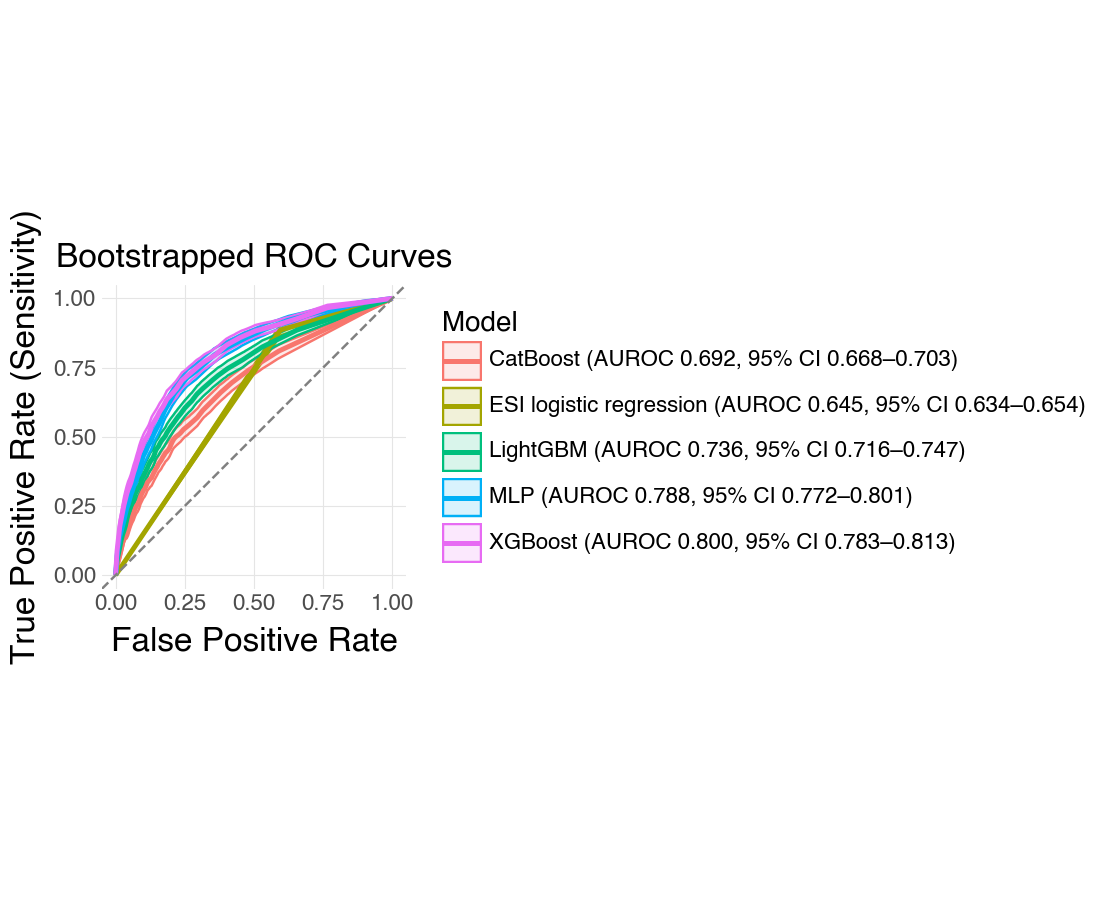

/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 5.5 x 4.5 in image.
/opt/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/pr_curve.pdf


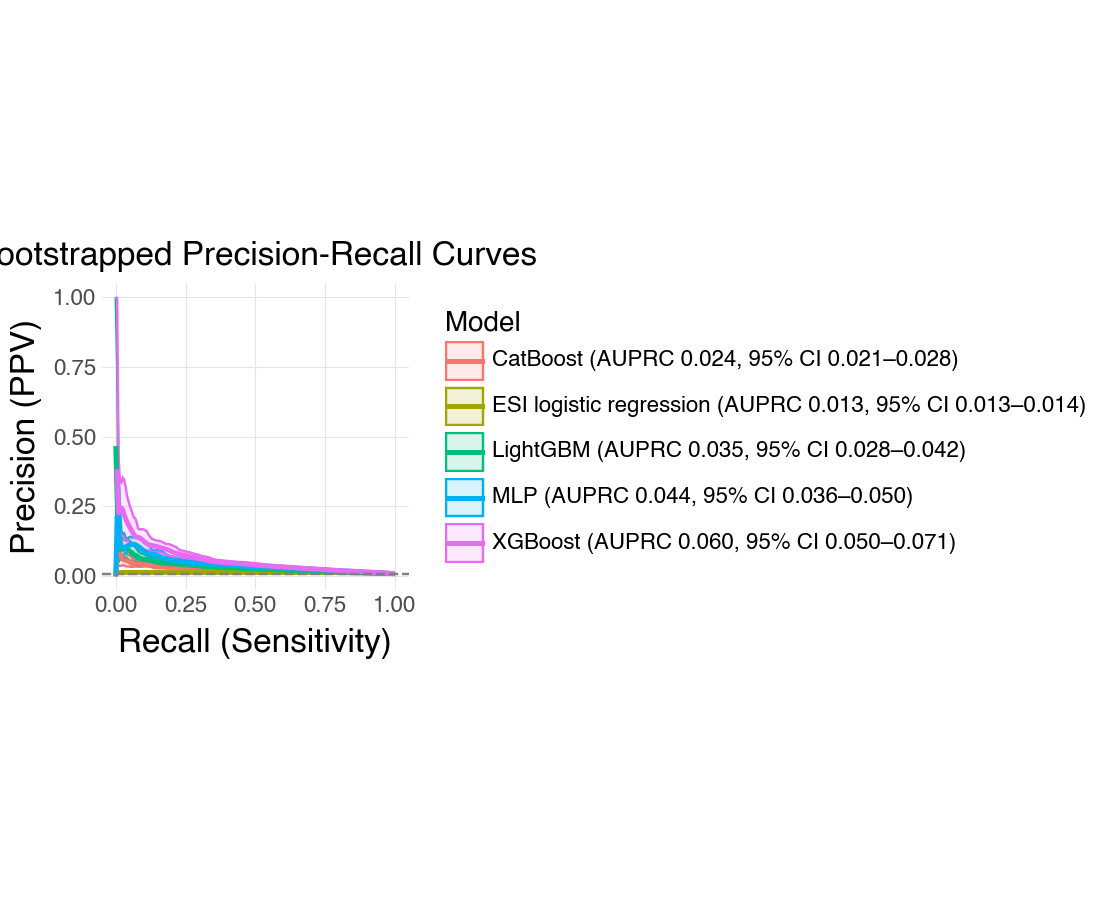

In [7]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score, average_precision_score
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line, geom_abline, annotate,
    labs, theme_minimal, theme, element_text, element_blank, element_line,
    coord_fixed
)

%matplotlib inline

# ============================================================
# 1. Load data
# ============================================================
test_df = pd.read_csv(save_filepath + "outputs/test-preds.csv", index_col=0)

models = test_df['Model'].unique().tolist()

# test-preds.csv is now LONG: one row per (test-set observation, model), with
# a 'Model' column and an 'index' column carried over from the original
# reset_index() in the prediction-building cell, which uniquely identifies
# the underlying test-set row and is shared across all models (they were all
# scored on the exact same test rows). Pivot to WIDE -- one row per test
# observation, one y_proba column per model -- so that every bootstrap
# resample below draws the SAME rows for every model. This is a paired
# bootstrap: it compares models on identical resampled patients each time,
# rather than letting each model see its own independent resample.
wide_df = test_df.pivot(index='index', columns='Model', values='y_proba')

y_true_by_row = test_df.groupby('index')['y_true'].nunique()
assert (y_true_by_row == 1).all(), (
    "y_true differs across models for at least one test-set row -- "
    "predictions for different models don't line up on the same test set."
)
wide_df['y_true'] = test_df.groupby('index')['y_true'].first()
wide_df = wide_df.reset_index(drop=True)

thresholds = np.linspace(0, 1, num=1001)
recall_grid = np.linspace(0, 1, num=201)
fpr_grid = np.linspace(0, 1, num=201)

# ============================================================
# 2. Point estimates on the real (non-resampled) data, per model.
#    These are the numbers you report; bootstraps supply the CI.
# ============================================================
point_rows = []
for model in models:
    y_true_full = wide_df['y_true'].values
    y_prob_full = wide_df[model].values
    auroc_point = roc_auc_score(y_true_full, y_prob_full)
    auprc_point = average_precision_score(y_true_full, y_prob_full)
    ap_lift_point = auprc_point / np.mean(y_true_full) if np.mean(y_true_full) > 0 else 0
    point_rows.append({
        'Model': model,
        'AUROC': auroc_point,
        'AUPRC': auprc_point,
        'AP_Lift': ap_lift_point,
    })
point_estimates = pd.DataFrame(point_rows).set_index('Model')

# ============================================================
# 3. Per-bootstrap threshold sweep -> confusion matrix counts, per model.
#    Kept for the sensitivity/specificity/PPV-vs-threshold table used
#    elsewhere (e.g. the false-alarm-ratio-vs-sensitivity plot). Each
#    bootstrap iteration resamples rows ONCE and reuses that same sample
#    for every model (see note in section 1).
# ============================================================
def bootstrap_sample(wide_df, thresholds, models, index):
    sampled = wide_df.sample(frac=1.0, replace=True, random_state=index)
    y_true = sampled['y_true'].values
    is_pos = y_true == 1
    is_neg = ~is_pos

    frames = []
    for model in models:
        y_prob = sampled[model].values
        preds_pos = y_prob[:, None] >= thresholds[None, :]

        tp = (preds_pos & is_pos[:, None]).sum(axis=0)
        fp = (preds_pos & is_neg[:, None]).sum(axis=0)
        fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
        tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

        frames.append(pd.DataFrame({
            'Index': index, 'Model': model, 'Threshold': thresholds,
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        }))
    return pd.concat(frames, ignore_index=True)

thresh_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_sample)(wide_df, thresholds, models, index)
    for index in range(1000)
)

thresh_results = pd.concat(thresh_results, ignore_index=True)

# ---- Metrics on the threshold table ----
def safe_div(numerator, denominator):
    return np.where(denominator > 0, numerator / np.where(denominator > 0, denominator, 1), 0.0)

tn, fp, fn, tp = (thresh_results[c].values for c in ['TN', 'FP', 'FN', 'TP'])

thresh_results['Sensitivity'] = safe_div(tp, tp + fn)
thresh_results['Specificity'] = safe_div(tn, tn + fp)
thresh_results['Youden Index'] = thresh_results['Sensitivity'] + thresh_results['Specificity'] - 1
thresh_results['FPR'] = safe_div(fp, tn + fp)
thresh_results['FNR'] = safe_div(fn, tp + fn)
thresh_results['NPV'] = safe_div(tn, fn + tn)
thresh_results['NNS'] = safe_div(fp + tp, tp)

# PPV and Lift are undefined (not zero) when no positive predictions were made.
no_positive_preds = (tp + fp) == 0
thresh_results['PPV'] = np.where(no_positive_preds, np.nan, tp / np.where(no_positive_preds, 1, tp + fp))
# Lift needs each row's OWN model's prevalence, since 'Model' varies per row now.
prevalence_by_model = wide_df['y_true'].mean()  # same underlying test set/prevalence for every model
thresh_results['Lift'] = thresh_results['PPV'].values / prevalence_by_model

thresh_results.to_csv(save_filepath + "outputs/thresholds-on-test-set.csv")

# ---- Summarise across bootstraps, per model (NaN-aware) ----
thresh_results_summarised = thresh_results.melt(
    id_vars=['Index', 'Model', 'Threshold'],
    var_name='Metric'
).groupby(['Model', 'Threshold', 'Metric']).agg(
    estimate=('value', lambda y: np.nanmean(y)),
    lower_conf=('value', lambda y: np.nanpercentile(y, 2.5)),
    upper_conf=('value', lambda y: np.nanpercentile(y, 97.5))
).reset_index()

thresh_results_summarised = thresh_results_summarised.pivot_table(
    index=['Model', 'Threshold'],
    columns='Metric',
    values=['estimate', 'lower_conf', 'upper_conf']
).reset_index()

thresh_results_summarised.columns = [
    '_'.join(col).strip('_') if col[1] else col[0]
    for col in thresh_results_summarised.columns
]

thresh_results_summarised.to_csv(save_filepath + "outputs/thresholds-on-test-set-summarised.csv")

# ============================================================
# 4. Bootstrapped ROC / PR curves, per model, correctly aligned.
#    Curves are interpolated onto a COMMON grid of FPR (ROC) /
#    recall (PR) per bootstrap, THEN aggregated across bootstraps.
#    This avoids mixing incomparable points across bootstraps that
#    happen to share a threshold but not a recall/FPR. Each bootstrap
#    iteration resamples rows ONCE and reuses that sample for every
#    model, for the same paired-comparison reason as section 3.
# ============================================================
def bootstrap_curves(wide_df, thresholds, fpr_grid, recall_grid, models, index):
    sampled = wide_df.sample(frac=1.0, replace=True, random_state=index)
    y_true = sampled['y_true'].values
    is_pos = y_true == 1
    is_neg = ~is_pos
    prevalence = np.mean(y_true)

    out = {}
    for model in models:
        y_prob = sampled[model].values
        preds_pos = y_prob[:, None] >= thresholds[None, :]

        tp = (preds_pos & is_pos[:, None]).sum(axis=0)
        fp = (preds_pos & is_neg[:, None]).sum(axis=0)
        fn = (~preds_pos & is_pos[:, None]).sum(axis=0)
        tn = (~preds_pos & is_neg[:, None]).sum(axis=0)

        sens = np.where((tp + fn) > 0, tp / np.where((tp + fn) > 0, tp + fn, 1), np.nan)
        fpr  = np.where((fp + tn) > 0, fp / np.where((fp + tn) > 0, fp + tn, 1), np.nan)
        ppv  = np.where((tp + fp) > 0, tp / np.where((tp + fp) > 0, tp + fp, 1), np.nan)

        # --- ROC: interpolate TPR onto common FPR grid ---
        order_roc = np.argsort(fpr)
        fpr_sorted, sens_for_roc = fpr[order_roc], sens[order_roc]
        valid_roc = ~np.isnan(fpr_sorted) & ~np.isnan(sens_for_roc)
        tpr_interp = np.interp(fpr_grid, fpr_sorted[valid_roc], sens_for_roc[valid_roc])
        auroc = np.trapz(tpr_interp, fpr_grid)

        # --- PR: interpolate precision onto common recall grid ---
        # Undefined-precision points (no positive predictions) are dropped, not zero-filled.
        order_pr = np.argsort(sens)
        sens_sorted, ppv_for_pr = sens[order_pr], ppv[order_pr]
        valid_pr = ~np.isnan(sens_sorted) & ~np.isnan(ppv_for_pr)
        ppv_interp = np.interp(recall_grid, sens_sorted[valid_pr], ppv_for_pr[valid_pr])
        auprc = np.trapz(ppv_interp, recall_grid)
        ap_lift = auprc / prevalence if prevalence > 0 else 0

        out[model] = (tpr_interp, ppv_interp, auroc, auprc, ap_lift)
    return out

curve_results = joblib.Parallel(n_jobs=8, verbose=1)(
    joblib.delayed(bootstrap_curves)(wide_df, thresholds, fpr_grid, recall_grid, models, index)
    for index in range(1000)
)

roc_rows, pr_rows, ci_rows = [], [], []
for model in models:
    tpr_matrix = np.array([r[model][0] for r in curve_results])   # (1000, len(fpr_grid))
    ppv_matrix = np.array([r[model][1] for r in curve_results])   # (1000, len(recall_grid))
    auroc_boot = np.array([r[model][2] for r in curve_results])
    auprc_boot = np.array([r[model][3] for r in curve_results])
    ap_lift_boot = np.array([r[model][4] for r in curve_results])

    roc_rows.append(pd.DataFrame({
        'Model': model,
        'FPR': fpr_grid,
        'TPR_est': tpr_matrix.mean(axis=0),
        'TPR_lc': np.percentile(tpr_matrix, 2.5, axis=0),
        'TPR_uc': np.percentile(tpr_matrix, 97.5, axis=0)
    }))
    pr_rows.append(pd.DataFrame({
        'Model': model,
        'Recall': recall_grid,
        'Precision_est': ppv_matrix.mean(axis=0),
        'Precision_lc': np.percentile(ppv_matrix, 2.5, axis=0),
        'Precision_uc': np.percentile(ppv_matrix, 97.5, axis=0)
    }))

    auroc_lc, auroc_uc = np.percentile(auroc_boot, [2.5, 97.5])
    auprc_lc, auprc_uc = np.percentile(auprc_boot, [2.5, 97.5])
    ap_lift_lc, ap_lift_uc = np.percentile(ap_lift_boot, [2.5, 97.5])
    ci_rows.append({
        'Model': model,
        'AUROC_lc': auroc_lc, 'AUROC_uc': auroc_uc,
        'AUPRC_lc': auprc_lc, 'AUPRC_uc': auprc_uc,
        'AP_Lift_lc': ap_lift_lc, 'AP_Lift_uc': ap_lift_uc,
    })

roc_plot_df = pd.concat(roc_rows, ignore_index=True)
pr_plot_df = pd.concat(pr_rows, ignore_index=True)
ci_df = pd.DataFrame(ci_rows).set_index('Model')

summary = point_estimates.join(ci_df)

roc_plot_df.to_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv")
pr_plot_df.to_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv")
summary.to_csv(save_filepath + "outputs/model-summary-metrics.csv")

# ---- AP Lift for every model ----
print("AP Lift by model:")
for model, row in summary.iterrows():
    print(f'  {model}: {row["AP_Lift"]:.3f} (95% CI {row["AP_Lift_lc"]:.3f}\u2013{row["AP_Lift_uc"]:.3f})')

# ============================================================
# 5. Plots -- all models on the same axes, color-coded by model.
#    Legend labels bake in each model's point AUROC/AUPRC so the
#    numbers are visible without separate annotate() calls per model.
# ============================================================

roc_plot_df = pd.read_csv(save_filepath + "outputs/roc-curve-bootstrapped.csv", index_col=0)
pr_plot_df = pd.read_csv(save_filepath + "outputs/pr-curve-bootstrapped.csv", index_col=0)

roc_label_map = {
    model: (
        f'{model} (AUROC {summary.loc[model, "AUROC"]:.3f}, '
        f'95% CI {summary.loc[model, "AUROC_lc"]:.3f}\u2013{summary.loc[model, "AUROC_uc"]:.3f})'
    )
    for model in models
}
pr_label_map = {
    model: (
        f'{model} (AUPRC {summary.loc[model, "AUPRC"]:.3f}, '
        f'95% CI {summary.loc[model, "AUPRC_lc"]:.3f}\u2013{summary.loc[model, "AUPRC_uc"]:.3f})'
    )
    for model in models
}
roc_plot_df['Label'] = roc_plot_df['Model'].map(roc_label_map)
pr_plot_df['Label'] = pr_plot_df['Model'].map(pr_label_map)

p_roc = (
    ggplot(roc_plot_df, aes(x='FPR', y='TPR_est', ymin='TPR_lc', ymax='TPR_uc',
                             color='Label', fill='Label'))
    + geom_ribbon(alpha=0.15)
    + geom_line(size=1)
    + geom_abline(intercept=0, slope=1, linetype='dashed', color='gray', size=0.5)
    + labs(title='Bootstrapped ROC Curves', x='False Positive Rate',
           y='True Positive Rate (Sensitivity)', color='Model', fill='Model')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(5.5, 4.5),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
        legend_title=element_text(size=10, weight='bold'),
        legend_text=element_text(size=8),
    )
)
p_roc.save(save_filepath + "outputs/roc_curve.pdf", dpi=300)
p_roc.show()

p_pr = (
    ggplot(pr_plot_df, aes(x='Recall', y='Precision_est', ymin='Precision_lc', ymax='Precision_uc',
                            color='Label', fill='Label'))
    + geom_ribbon(alpha=0.15)
    + geom_line(size=1)
    + geom_abline(intercept=wide_df['y_true'].mean(), slope=0, linetype='dashed', color='gray', size=0.5)
    + labs(title='Bootstrapped Precision-Recall Curves', x='Recall (Sensitivity)',
           y='Precision (PPV)', color='Model', fill='Model')
    + coord_fixed(ratio=1)
    + theme_minimal(base_size=10)
    + theme(
        figure_size=(5.5, 4.5),
        plot_title=element_text(size=12, weight='bold'),
        panel_grid_minor=element_blank(),
        panel_grid_major=element_line(size=0.4),
        axis_title=element_text(size=12, weight='bold'),
        legend_title=element_text(size=10, weight='bold'),
        legend_text=element_text(size=8),
    )
)
p_pr.save(save_filepath + "outputs/pr_curve.pdf", dpi=300)
p_pr.show()

Print tables as summary metrics.

In [22]:

#Load summary metrics.
summary = pd.read_csv(save_filepath + "outputs/model-summary-metrics.csv")

def ci_label(row, point_col, lc_col, uc_col):
    return f'{row[point_col]:.3f} ({row[lc_col]:.3f}\u2013{row[uc_col]:.3f})'

summary['AUROC_label'] = summary.apply(ci_label, axis=1, args=('AUROC', 'AUROC_lc', 'AUROC_uc'))
summary['AUPRC_label'] = summary.apply(ci_label, axis=1, args=('AUPRC', 'AUPRC_lc', 'AUPRC_uc'))
summary['AP_label'] = summary.apply(ci_label, axis=1, args=('AP_Lift', 'AP_Lift_lc', 'AP_Lift_uc'))

summary = summary[['Model', 'AUROC_label', "AUPRC_label", "AP_label"]]
summary['Model'] = pd.Categorical(summary['Model'], categories=['ESI logistic regression', 'CatBoost', 'LightGBM', 'MLP', 'XGBoost'], ordered=True)
summary = summary.sort_values('Model')

print(summary.to_latex())



\begin{tabular}{lllll}
\toprule
 & Model & AUROC_label & AUPRC_label & AP_label \\
\midrule
4 & ESI logistic regression & 0.645 (0.634–0.654) & 0.013 (0.013–0.014) & 1.429 (1.416–1.486) \\
0 & CatBoost & 0.692 (0.668–0.703) & 0.024 (0.021–0.028) & 2.629 (2.278–2.928) \\
2 & LightGBM & 0.736 (0.716–0.747) & 0.035 (0.028–0.042) & 3.739 (3.081–4.459) \\
3 & MLP & 0.788 (0.772–0.801) & 0.044 (0.036–0.050) & 4.675 (3.997–5.312) \\
1 & XGBoost & 0.800 (0.783–0.813) & 0.060 (0.050–0.071) & 6.424 (5.330–7.511) \\
\bottomrule
\end{tabular}



What are the metrics we care about? We want to minimise the number of false alarms (i.e. minimise FPR) while maximising the fraction of cases that are actually caught (i.e. maximise TPR).
Alternatively we can maximise the value of the signal (maximise PPV) while minimising false negative rate (fraction of people who are missed).

This is of course assuming a 2-bucket scheme.
But for a single threshold, this is what we end up with. What is the optimal threshold for this?

Next we'd have to think about having, essentially, multiple risk buckets.

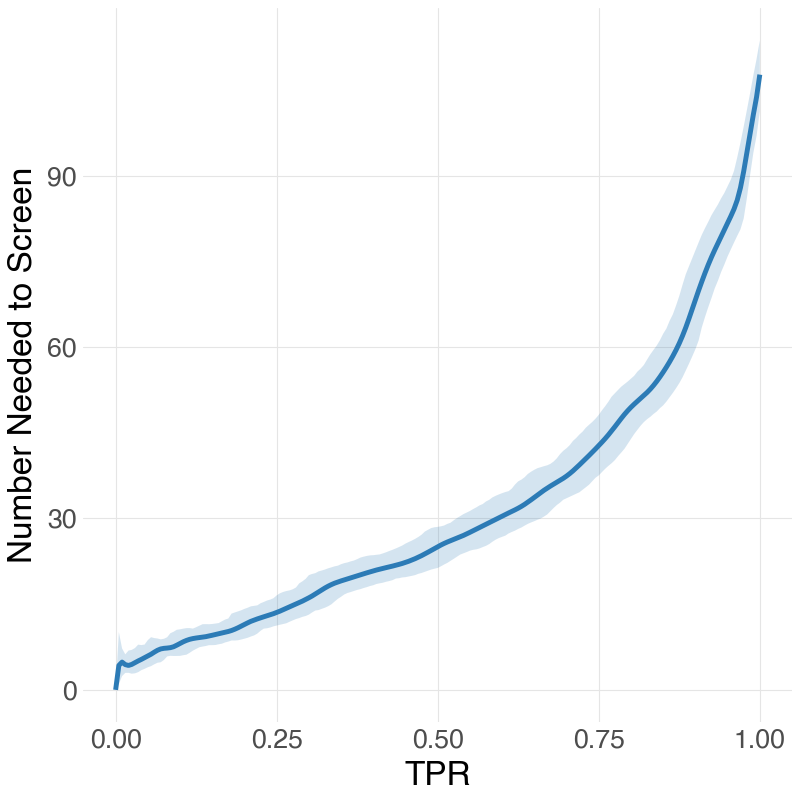

<Figure size 640x480 with 0 Axes>

In [86]:
%matplotlib inline

import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_ribbon, geom_line,
    labs, theme_minimal, theme,
    element_text, element_blank, element_line
)

# Load raw per-bootstrap, per-threshold results (NOT the summarised version —
# we need each bootstrap's individual curve to interpolate correctly).
thresh_results = pd.read_csv(save_filepath + "outputs/thresholds-on-test-set.csv", index_col=0)
thresh_results = thresh_results[thresh_results['Model']==target_model].copy().reset_index()


def interpolate_metric_pair(df, x_metric, y_metric, x_grid):
    """
    For each bootstrap, sort by x_metric and interpolate y_metric onto a
    common x_grid. Returns a matrix of shape (n_bootstraps, len(x_grid)).
    """
    curves = []
    for idx, g in df.groupby('Index'):
        g = g.sort_values(x_metric)
        x_vals = g[x_metric].values
        y_vals = g[y_metric].values

        valid = ~np.isnan(x_vals) & ~np.isnan(y_vals)
        x_vals, y_vals = x_vals[valid], y_vals[valid]

        # np.interp requires x_vals ascending and unique-ish; sort handles ascending.
        # Where x_metric has duplicate values (flat regions), interp just uses the
        # first match in sorted order, which is fine for monotonic-ish metrics.
        y_interp = np.interp(x_grid, x_vals, y_vals)
        curves.append(y_interp)

    return np.array(curves)  # shape (n_bootstraps, len(x_grid))


def plot_metrics_interpolated(x, y, title, x_name=None, y_name=None,
                               x_grid=None, n_grid=201, fill='#2c7bb6', color='#2c7bb6'):

    if x_grid is None:
        x_grid = np.linspace(0, 1, n_grid)

    y_matrix = interpolate_metric_pair(thresh_results, x, y, x_grid)

    plot_df = pd.DataFrame({
        x: x_grid,
        'estimate': np.nanmean(y_matrix, axis=0),
        'lower_conf': np.nanpercentile(y_matrix, 2.5, axis=0),
        'upper_conf': np.nanpercentile(y_matrix, 97.5, axis=0)
    })

    p = (
        ggplot(plot_df, aes(x=x, y='estimate', ymin='lower_conf', ymax='upper_conf'))
        + geom_ribbon(alpha=0.2, fill=fill)
        + geom_line(size=1, color=color)
        + labs(
            title=title,
            x=x if x_name is None else x_name,
            y=y if y_name is None else y_name
        )
        + theme_minimal(base_size=12)
        + theme(
            figure_size=(4, 4),
            plot_title=element_text(size=16, weight='bold'),
            plot_subtitle=element_text(size=8),
            panel_grid_minor=element_blank(),
            panel_grid_major=element_line(size=0.4),
            axis_title=element_text(size=12, weight='bold'),
        )
    )

    p.show()
    return p

plt.figure()
p = plot_metrics_interpolated(
    'Sensitivity', 'NNS',
    '',
    x_name='TPR',
    y_name='Number Needed to Screen'
)
plt.tight_layout()
plt.savefig(save_filepath + "outputs/num-needed-screen.pdf", dpi=300, bbox_inches="tight")
plt.show()



Explain the chosen XGBoost model's predictions with a SHAP beeswarm plot.

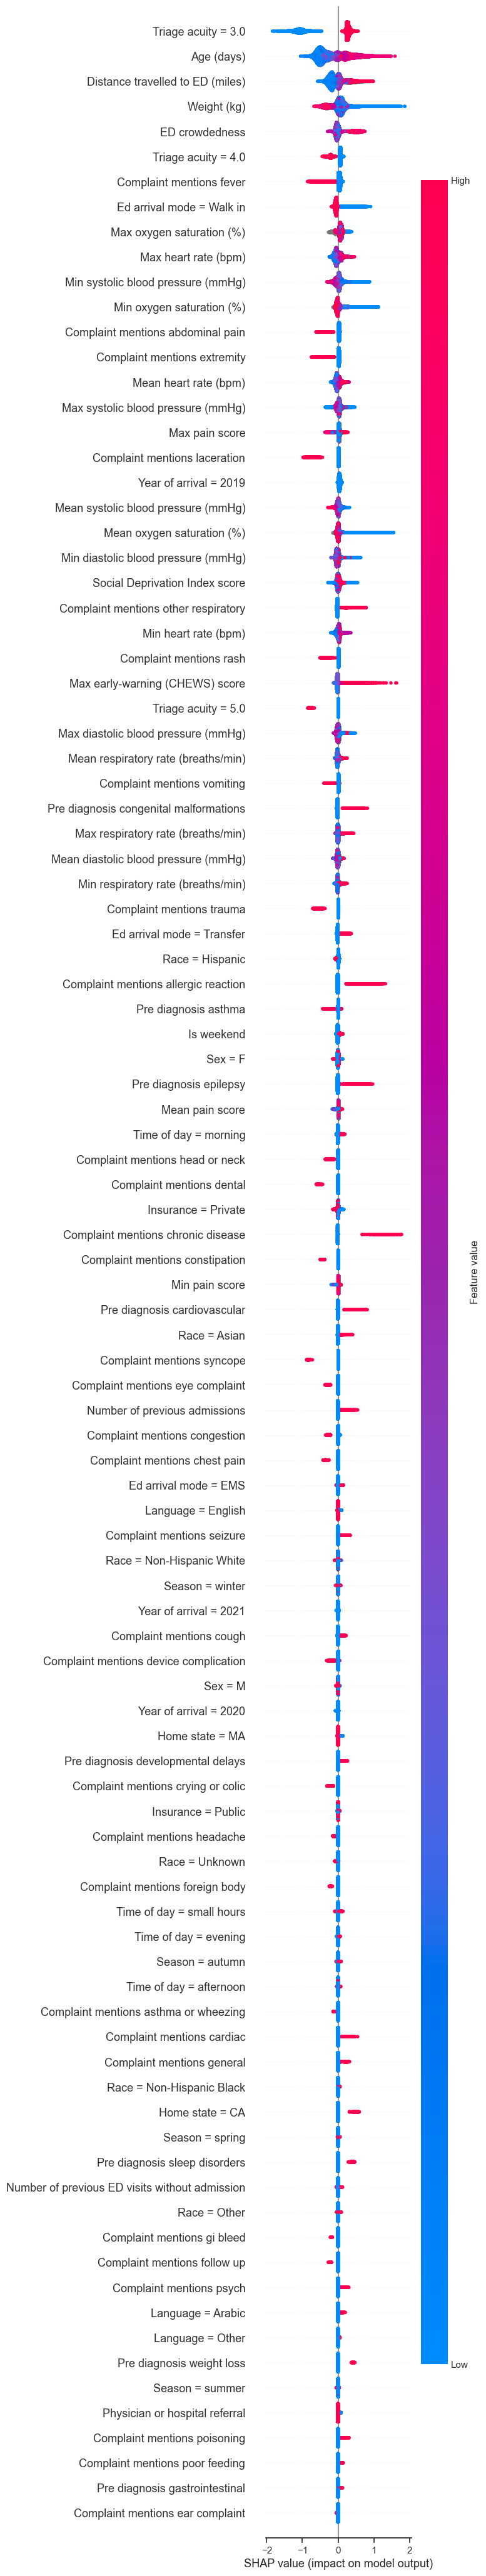

In [24]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

#Load the fitted XGBoost model, its feature names, and the test split.
fitted_models = joblib.load(save_filepath + "outputs/fitted-models.joblib")
xgb_model = fitted_models["xgboost"]
feature_names = fitted_models["feature_names"]
#xgb_model is the sklearn Pipeline built in cell 9; the classifier itself is the "model" step.
xgb_estimator = xgb_model.named_steps["model"]

[X_train, X_test, y_train, y_test, csn_train, csn_test, _, _] = joblib.load(save_filepath + "outputs/split.joblib")

#Sanity check: fitted-models.joblib and split.joblib should always be saved together by the
#same run of cell 9, but if an old split.joblib or fitted-models.joblib is loaded alongside a
#newer one (e.g. only one of the two files got overwritten), this catches it immediately
#instead of silently mislabeling every column below.
assert len(feature_names) == X_test.shape[1], (
    f"Feature count mismatch: fitted-models.joblib has {len(feature_names)} feature names but "
    f"X_test (from split.joblib) has {X_test.shape[1]} columns. These two files are likely out "
    f"of sync -- re-run cell 9 (which saves both together) before trusting the plot below."
)

X_test_named = X_test.copy()
X_test_named.columns = feature_names

#-----HUMAN-READABLE FEATURE LABELS (shared by this SHAP plot and the PDP grid below)-----
#Built generically rather than as one giant hardcoded table, so it also covers one-hot
#categorical levels (e.g. specific home_state or race values) we haven't enumerated by hand.
VITAL_LABELS = {
    'hr': 'heart rate (bpm)',
    'rr': 'respiratory rate (breaths/min)',
    'sbp': 'systolic blood pressure (mmHg)',
    'dbp': 'diastolic blood pressure (mmHg)',
    'sp_o2': 'oxygen saturation (%)',
    'pain': 'pain score',
}
STAT_PREFIX_LABELS = {'max': 'Max', 'mean': 'Mean', 'min': 'Min'}
BASE_FEATURE_LABELS = {
    'age_in_days': 'Age (days)',
    'miles_travelled': 'Distance travelled to ED (miles)',
    'sdi_score': 'Social Deprivation Index score',
    'crowdedness': 'ED crowdedness',
    'raw_weight': 'Weight (kg)',
    'max_early_chews_score': 'Max early-warning (CHEWS) score',
    'num_previous_admissions': 'Number of previous admissions',
    'num_previous_visits_without_admission': 'Number of previous ED visits without admission',
}

def humanize_feature_name(name):
    """Best-effort human-readable label for a (possibly one-hot-encoded) feature name."""
    if name in BASE_FEATURE_LABELS:
        return BASE_FEATURE_LABELS[name]

    #Vitals of the form max_hr / mean_sp_o2 / min_pain etc.
    for prefix, prefix_label in STAT_PREFIX_LABELS.items():
        if name.startswith(prefix + '_'):
            base = name[len(prefix) + 1:]
            if base in VITAL_LABELS:
                return f"{prefix_label} {VITAL_LABELS[base]}"

    #complaint_contains_X -> "Complaint mentions X"
    if name.startswith('complaint_contains_'):
        return f"Complaint mentions {name[len('complaint_contains_'):].replace('_', ' ')}"

    #One-hot categorical dummies (e.g. "triage_acuity_3.0", "ed_arrival_mode_Walk in",
    #"year_of_arrival_2019", "race_White", ...): show as "Base label = level".
    for cat_col in categorical_predictors:
        prefix = cat_col + '_'
        if name.startswith(prefix):
            level = name[len(prefix):]
            return f"{cat_col.replace('_', ' ').capitalize()} = {level}"

    #Fallback: just humanise the raw name.
    return name.replace('_', ' ').capitalize()

FEATURE_LABELS = {name: humanize_feature_name(name) for name in feature_names}

#SHAP beeswarm plot for the chosen XGBoost model on the held-out test set.
explainer = shap.TreeExplainer(xgb_estimator)
shap_values = explainer.shap_values(X_test_named)

plt.figure()
shap.summary_plot(
    shap_values, X_test_named,
    feature_names=[FEATURE_LABELS.get(c, c) for c in X_test_named.columns],
    max_display=100,
    show=False,
)
plt.tight_layout()
plt.savefig(save_filepath + "outputs/shap_beeswarm.pdf", dpi=300, bbox_inches="tight")
plt.show()

Generating 2 pairwise partial dependence plots (of 325 possible)...

Missingness among selected features:
mean_hr        0.14110
raw_weight     0.02693
age_in_days    0.00000

88525 of 105606 test rows are complete across all 3 selected features (83.8%).


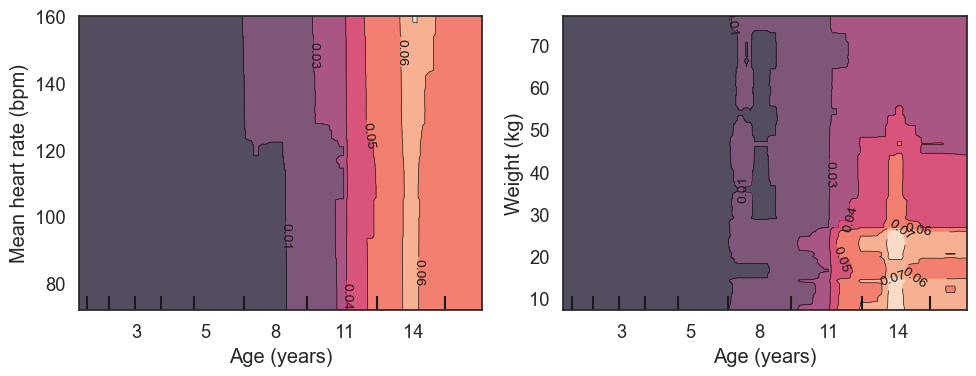

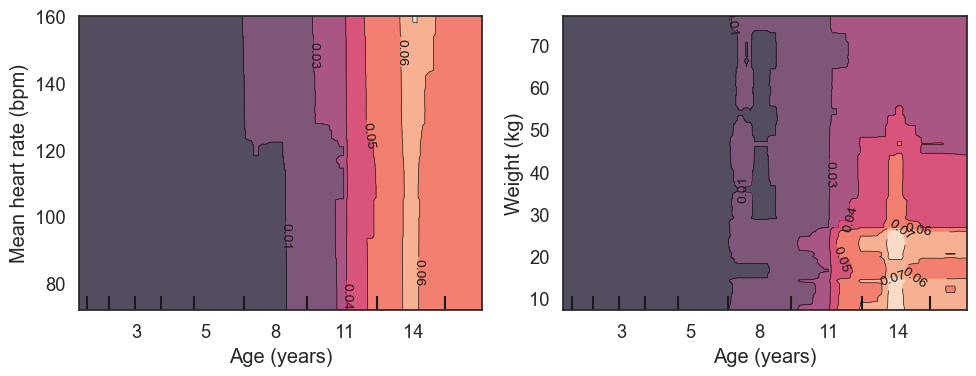

In [27]:
from sklearn.inspection import PartialDependenceDisplay
from matplotlib.ticker import FuncFormatter
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Take continuous predictors.
PDP_SAMPLE_SIZE = 2000   #PDP is an average over the data, so a representative subsample is fine and much faster
GRID_RESOLUTION = 100
N_COLS = 2

#feature_names/xgb_estimator/X_test_named/FEATURE_LABELS come from the SHAP cell above (same kernel session).
cts_to_plot = ['mean_hr', 'raw_weight']
top_continuous = ['age_in_days'] + cts_to_plot
pairs = [['age_in_days', s] for s in cts_to_plot]
print(f"Generating {len(pairs)} pairwise partial dependence plots (of {len(continuous_predictors)*(len(continuous_predictors)-1)//2} possible)...")

missingness = X_test_named[top_continuous].isna().mean().sort_values(ascending=False)
print("\nMissingness among selected features:")
print(missingness.to_string())

complete_case = X_test_named[top_continuous].notna().all(axis=1)
n_complete = complete_case.sum()
print(f"\n{n_complete} of {len(X_test_named)} test rows are complete across all {len(top_continuous)} selected features "
      f"({n_complete/len(X_test_named):.1%}).")
if n_complete < PDP_SAMPLE_SIZE:
    print(f"WARNING: fewer complete-case rows than PDP_SAMPLE_SIZE ({PDP_SAMPLE_SIZE}) -- using all {n_complete} available.")

pdp_sample = X_test_named[complete_case].sample(min(PDP_SAMPLE_SIZE, n_complete), random_state=RANDOM_STATE)

n_rows = int(np.ceil(len(pairs) / N_COLS))
display = PartialDependenceDisplay.from_estimator(
    xgb_estimator,
    pdp_sample,
    features=pairs,
    feature_names=list(pdp_sample.columns),
    kind="average",
    grid_resolution=GRID_RESOLUTION,
    n_cols=N_COLS,
    n_jobs=-1,
)
display.figure_.set_size_inches(5 * N_COLS, 4 * n_rows)

#Relabel axes with human-readable names. age_in_days is shown in years for readability -- this
#only rescales the tick labels/title, NOT the underlying grid, which is still built and
#evaluated in days (the unit the model was actually trained on).
DAYS_PER_YEAR = 365.25
age_year_formatter = FuncFormatter(lambda days, _: f"{days / DAYS_PER_YEAR:.0f}")

for ax, (f_x, f_y) in zip(display.axes_.ravel(), pairs):
    ax.set_xlabel(FEATURE_LABELS.get(f_x, f_x))
    ax.set_ylabel(FEATURE_LABELS.get(f_y, f_y))
    if f_x == 'age_in_days':
        ax.xaxis.set_major_formatter(age_year_formatter)
        ax.set_xlabel("Age (years)")
    if f_y == 'age_in_days':
        ax.yaxis.set_major_formatter(age_year_formatter)
        ax.set_ylabel("Age (years)")

plt.tight_layout()
display.figure_.savefig(save_filepath + "outputs/pdp_2d_top_continuous.pdf", dpi=300, bbox_inches="tight")
plt.show()

Look at 2D partial dependence plots for continuous predictors.